<a href="https://colab.research.google.com/github/olchan/DEEPLEARNINGstudy/blob/main/%5B%EB%85%BC%EB%AC%B8_%EB%A6%AC%EB%B7%B0%5D_SGDR_%26_AdamW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AdamW : Decoupled Weight Decay Regularization
- 기존의 SGD 같은 옵티마이저에서는 L2 정규화(L2 Regularization) 와 가중치 감쇠(Weight Decay) 가 수학적으로 완전히 같은 행위였음

- 그런데, adam에서는 두 방법이 완전히 다르게 동작하게 되었고, 이 때문에 모델 성능이 떨어지는 문제가 발생함

- **Adam에서 기존 방식(L2)을 쓰면 의도했던 정규화 효과가 깨지기에, 이러한 문제 해결을 위해 adamW가 등장함**

In [ ]:
# adam 자체에는 문제가 없음
# 다만, 개발자들이 Adam 코드를 짤 때 L2 정규화를 Weight Decay의 목적으로 사용했는데
# 기존 SGD 방식의 L2 정규화 구현 코드를 Adam에 그대로 사용하는 과정에서 문제가 생겼음
"""
많은 사람들이 "L2 = Weight Decay" 까지만 알고 코드에 적용해왔지만.
Adam에 넣었을 때 어떻게 되는지는 자세히 보지 않고 적용하다보니 문제가 발생했음
"""
#  잘못된 구현 방식으로 인해, weight decay의 역할을 제대로 하지 못 하였음
# 그래서, 문제가 생기지 않도록, Weight Decay 항을 따로 분리 시킨 adamW가 제안됨
# 이를 통해 Adam의 빠른 수렴 속도와 L2 규제의 오버피팅 방지 효과를 동시에 누릴 수 있게 됨

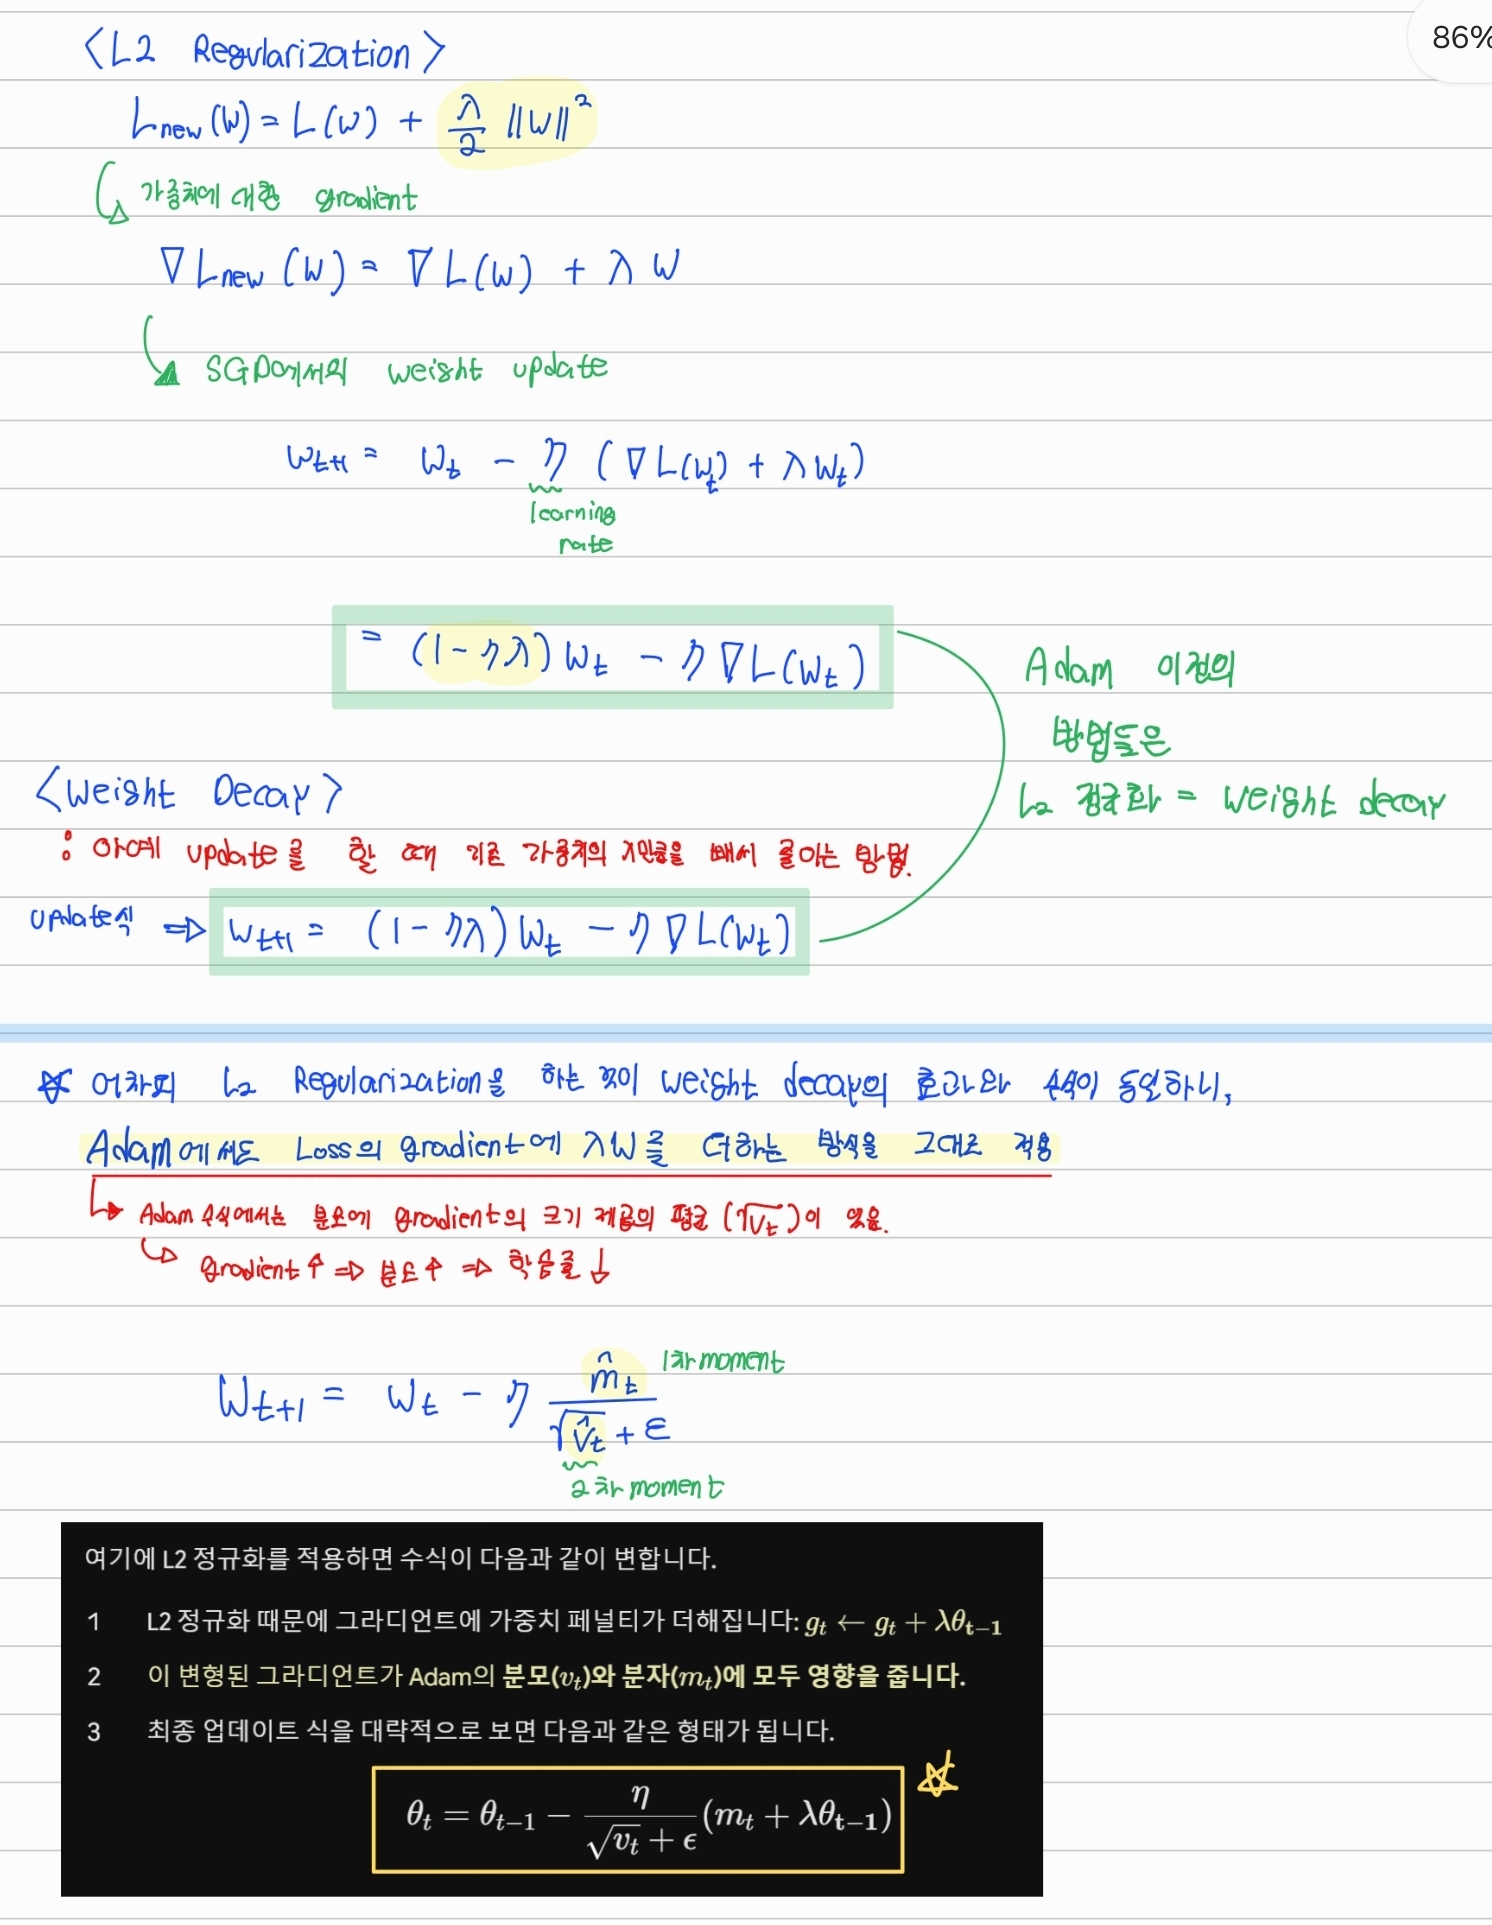

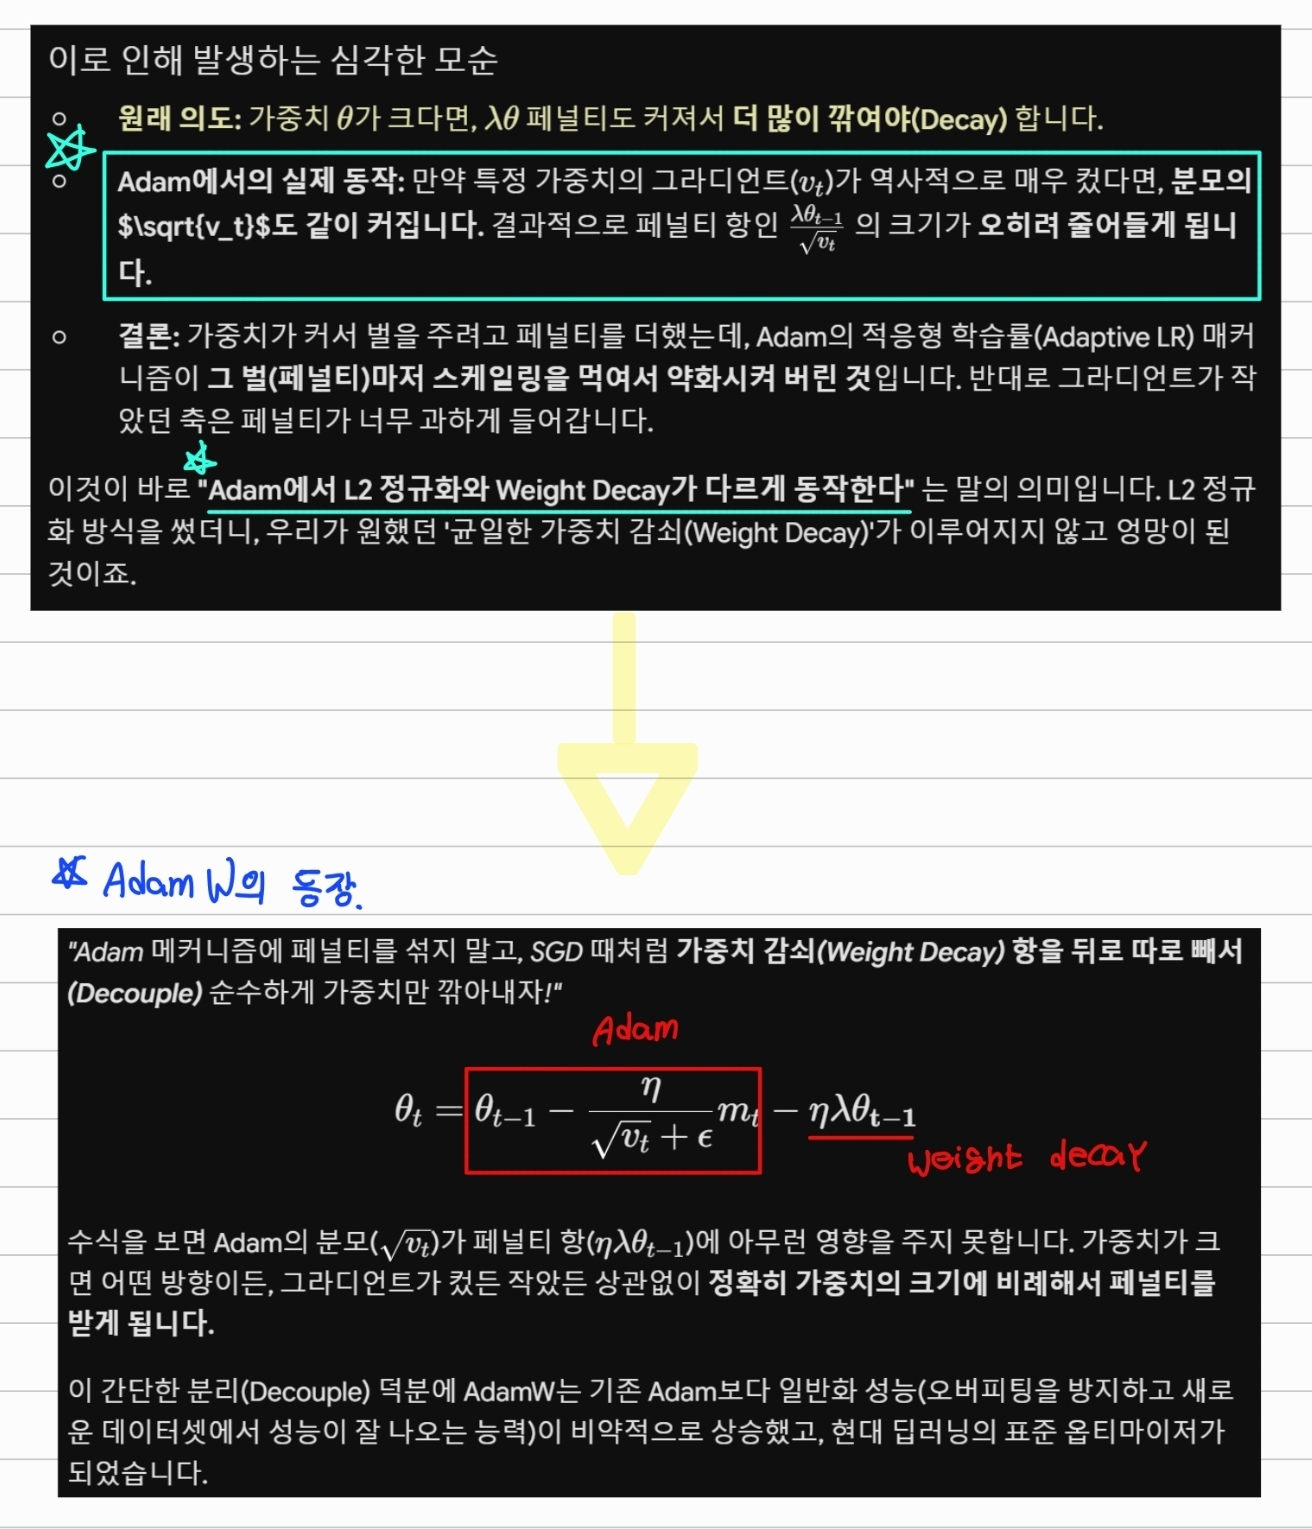

>  Schedule Multiplier ($\eta_t$) 의 역할
- $\eta_t$ (Schedule Multiplier) 의 용도 : 주로 코사인 어닐링(Cosine Annealing)이나 웜 스타트(Warm Restarts) 같은 러닝 레이트 스케줄러(Learning Rate Scheduler) 에 의해 매 스텝마다 바뀌는 $0 \sim 1$ 사이의 비율(혹은 특정 배율)

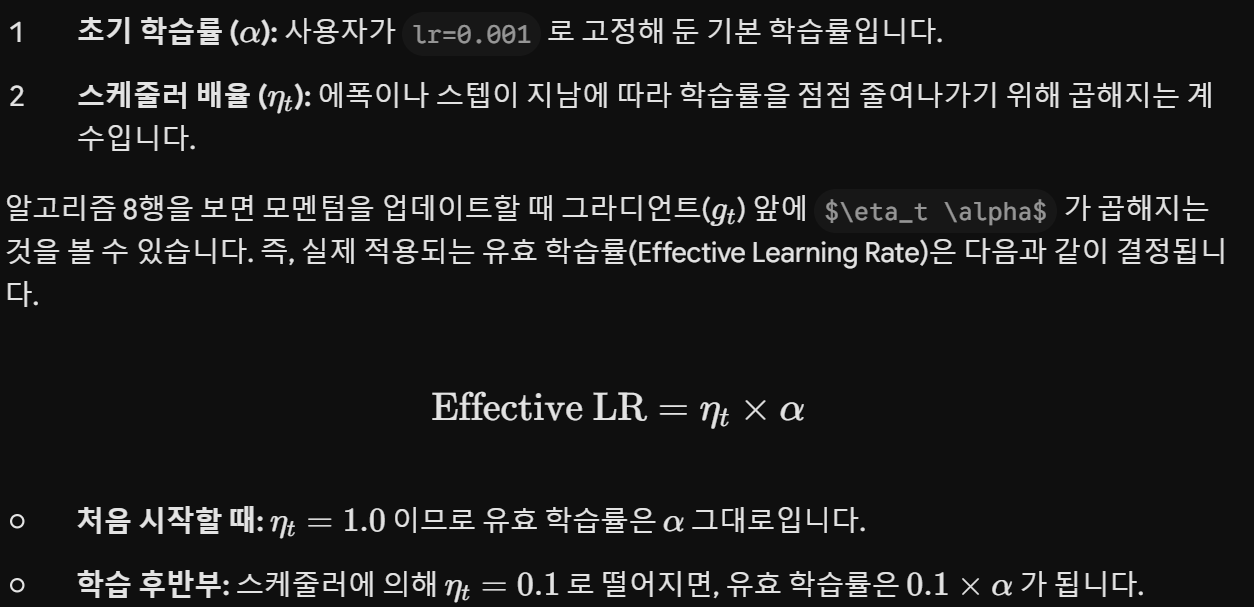

> Adam 자체적으로 $m_t$ (1차 모멘트: 방향)와 $v_t$ (2차 모멘트: 보폭)를 사용해 파라미터별로 학습률을 '적응형(Adaptive)'으로 조절하는데, 왜 Cosine Annealing 같은 스케줄러를 추가로 결합해서 전체 학습률을 한 번 더 조절하는가?

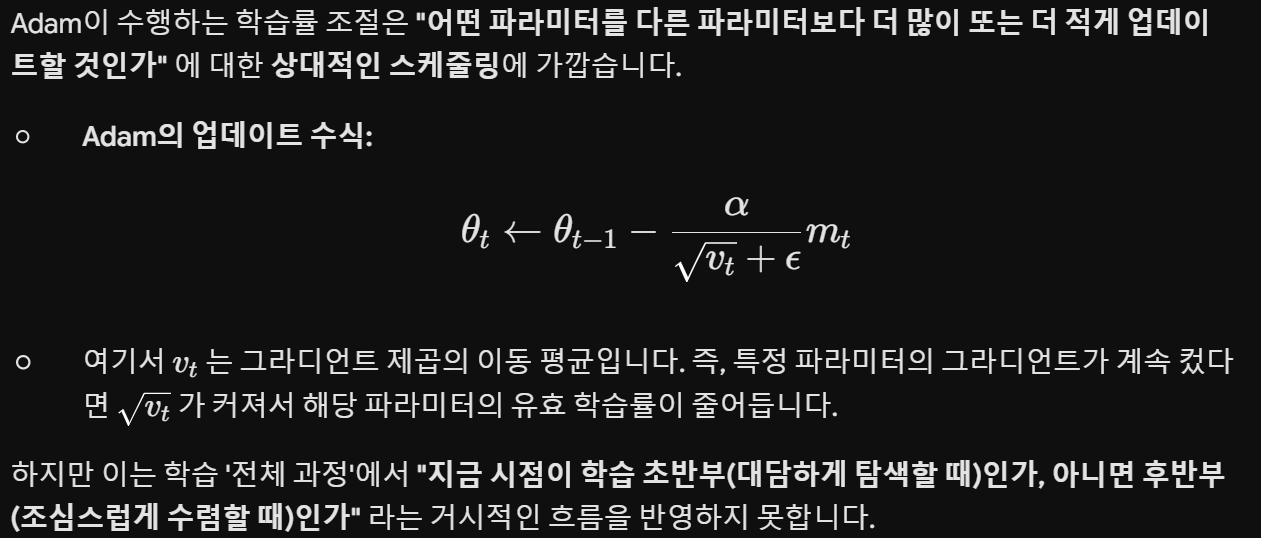

> We also demonstrate that our decoupled weight decay renders the optimal settings of the learning rate and the weight decay factor much more independent, thereby easing hyperparameter optimization

In [ ]:
# adam에서의 문제 : learning rate를 바꾸면? Adam에서는 weight decay가 작동하는 방식까지 함께 변화했음.
# 따라서, learning rate를 바꾸면 weight decay도 다시 튜닝해야 했음.

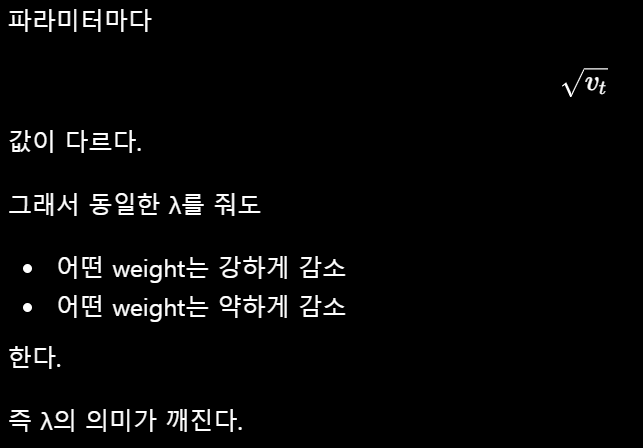

In [ ]:
# adamW의 경우에는 gradient에 λw를 넣지 않고 업데이트 마지막에 따로 적용하기에 weight decay가 1/루트(vt)의 영향을 받지 않음

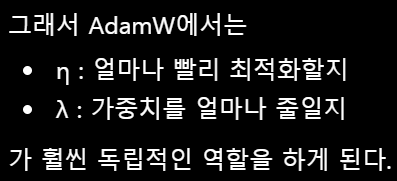

> 결과를 보면, WR(Warm Restarts) 기법을 섞은 방식이 초반 수렴 속도도 압도적으로 빠르고, 결과적으로 아주 훌륭한 최종 성능을 보인다.

- Warm Restart : 이 코사인 곡선을 따라 학습률이 0까지 떨어졌을 때, "모델의 가중치($\theta$)는 지금까지 학습한 상태 그대로 유지(Warm)한 채, 오직 '학습률'만 다시 최댓값으로 통통 튀겨서 재시작(Restart)" 하는 기법을 의미

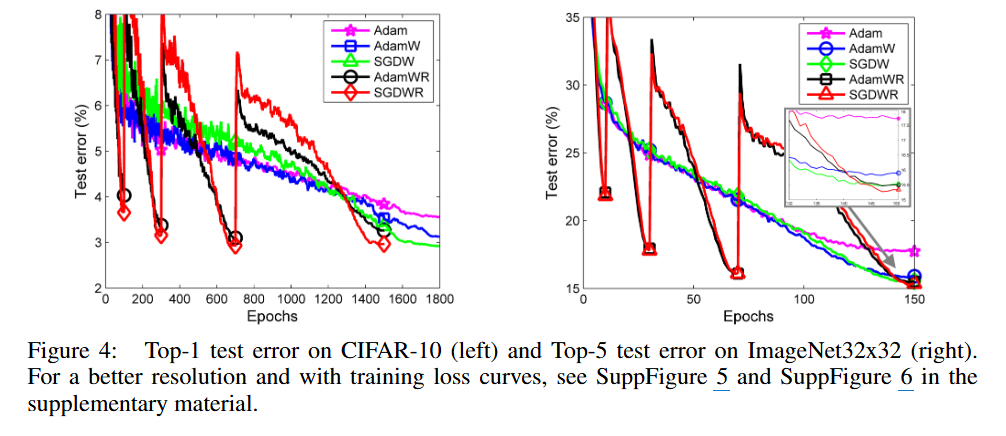

# SGDR: Stochastic Gradient Descent with Warm Restarts
- Anytime Performance : "학습이 언제 중단되더라도 그 시점까지 가능한 한 좋은 성능을 내는 능력"

In [ ]:
# 논문이 나온 당시에는 아래와 같이 learning rate을 설정해서 학습함

# step decay
epoch 0~80     : 0.1
epoch 80~120   : 0.01
epoch 120~160  : 0.001

# 언제 learning rate를 떨어뜨릴지 사람이 정해야 했고,
# 너무 갑자기 떨어지며, 찾은 해가 최적의 해인지 local minima인지 모르는 문제가 있었음

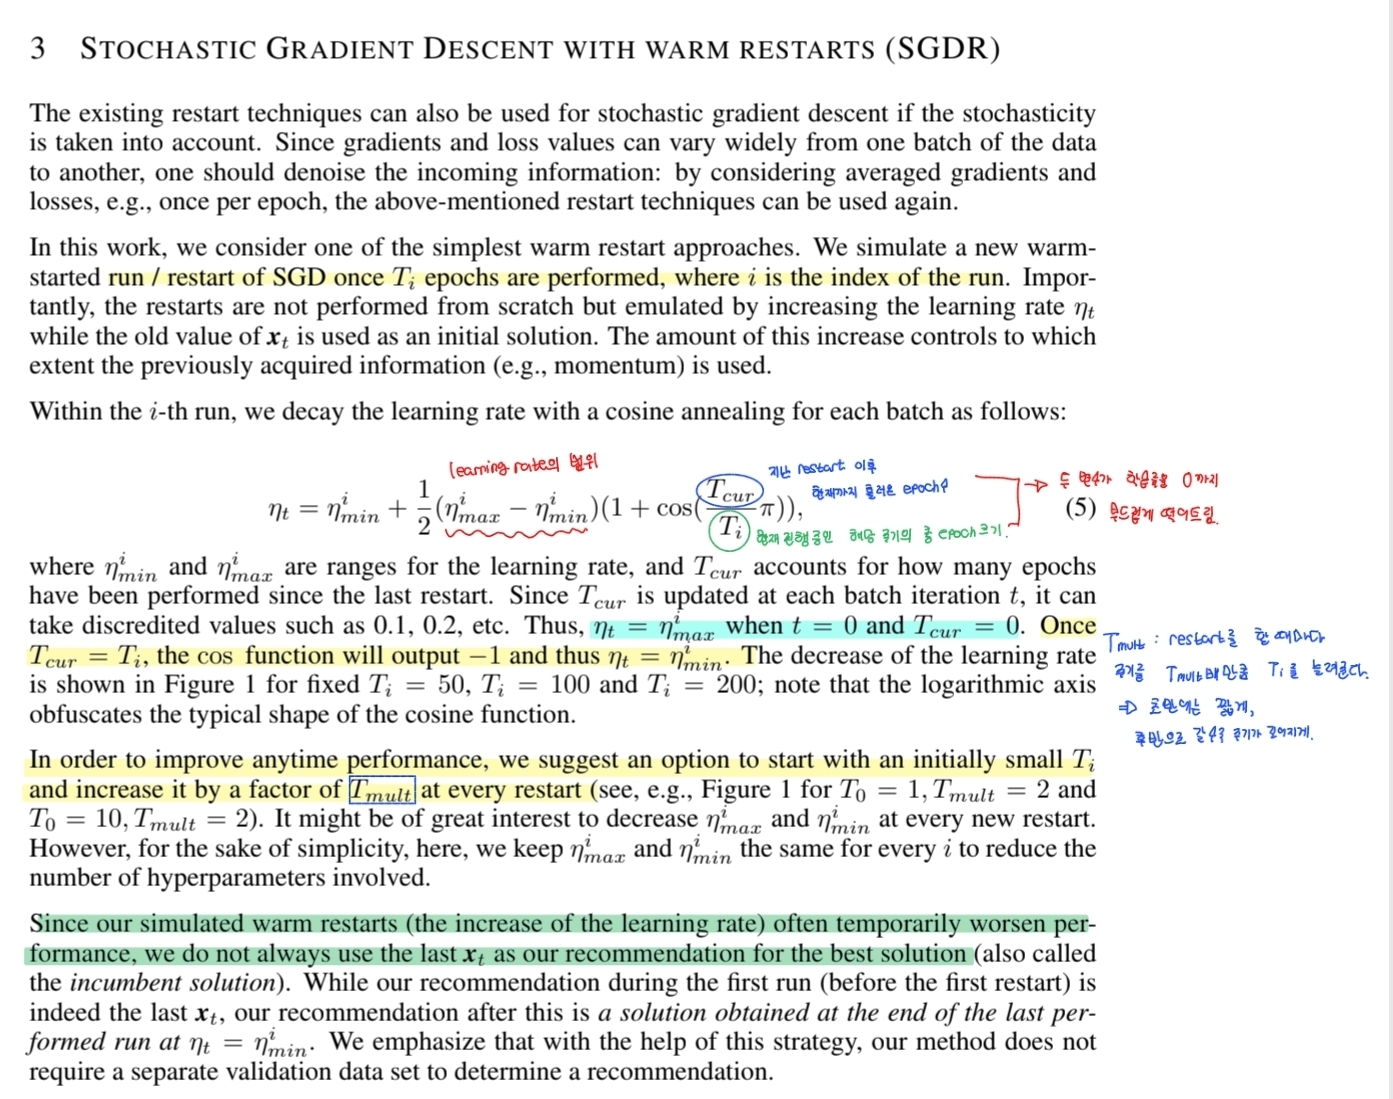

In [ ]:
# 논문에서 추천한 hyper parmeter 값
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=10,       # 총 에폭의 5%~10% 수준으로 시작
    T_mult=2      # 주기를 2배씩 늘려나감
)

> 해당 논문에서는 SGD + Momentum을 대상으로 warmm restarts를 적용했으나, 현재는 adamW와 결합해서 사용

## Pytorch 구현 : 최근에는 AdamW + Cosine Annealing Scheduler를 많이 사용
- torch.optim.AdamW & torch.optim.lr_scheduler.CosineAnnealingLR

>> "코사인 모양으로 줄였다가 갑자기 최댓값으로 리셋(Restart) 하는 것"이 논문의 핵심인데, 현대 딥러닝(LLM, VLM)에서 대형 모델을 학습시킬 때는 팅겨내지 않고 처음부터 끝까지 단 한 번의 커다란 코사인 곡선만 그리며 0으로 부드럽게 수렴시키는 방식을 많이 사용한다. -> 거대 모델은 한 번 학습률을 0 근처까지 떨어뜨려 안정화(착륙)시키는 데만 수억 원의 비용과 수주일의 시간이 걸리기에, 안정적으로 loss가 수렴하던 모델을 갑자기 warm restart로 튕겨버리면 모델을 다시 수렴시키늗데 너무 오랜 시간이 걸려 risk가 너무 크기에 잘 사용하지 않음

In [ ]:
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler

# 1. 옵티마이저는 가중치 감쇠가 수리적으로 분리된 AdamW를 고른다.
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)

# 2. 뒤에 스케줄러로 코사인 어닐링(with Restarts)을 붙인다.
# 여기서 T_0가 주기, T_mult가 주기를 늘려나가는 승수입니다.
scheduler = lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)

optimizer.step()      # 가중치 업데이트
scheduler.step()      # learning rate 조정

In [ ]:
for epoch in range(num_epochs):

    for x, y in train_loader:

        optimizer.zero_grad()

        output = model(x)
        loss = criterion(output, y) # loss 계산

        loss.backward() # gradient 계산

        optimizer.step() # optimizer를 통한 update

    scheduler.step() # learning rate update